#### **EDA - Travel Data**

This dataset contains customer information and their interactions related to product pitches in the travel and tourism domain. It includes demographic attributes (age, gender, marital status, occupation), engagement-related features (type of contact, number of follow-ups, duration of pitch, satisfaction score), and lifestyle indicators (passport ownership, car ownership, number of trips, children visiting). The target variable ProdTaken indicates whether the customer accepted the product offer.

The data is useful for analyzing customer behavior, identifying patterns in product adoption, and evaluating factors influencing travel-related purchase decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Travel.csv')
df

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,204883,1,49.0,Self Enquiry,3,9.0,Small Business,Male,3,5.0,Deluxe,4.0,Unmarried,2.0,1,1,1,1.0,Manager,26576.0
4884,204884,1,28.0,Company Invited,1,31.0,Salaried,Male,4,5.0,Basic,3.0,Single,3.0,1,3,1,2.0,Executive,21212.0
4885,204885,1,52.0,Self Enquiry,3,17.0,Salaried,Female,4,4.0,Standard,4.0,Married,7.0,0,1,1,3.0,Senior Manager,31820.0
4886,204886,1,19.0,Self Enquiry,3,16.0,Small Business,Male,3,4.0,Basic,3.0,Single,3.0,0,5,0,2.0,Executive,20289.0


In [3]:
df.dtypes

CustomerID                    int64
ProdTaken                     int64
Age                         float64
TypeofContact                object
CityTier                      int64
DurationOfPitch             float64
Occupation                   object
Gender                       object
NumberOfPersonVisiting        int64
NumberOfFollowups           float64
ProductPitched               object
PreferredPropertyStar       float64
MaritalStatus                object
NumberOfTrips               float64
Passport                      int64
PitchSatisfactionScore        int64
OwnCar                        int64
NumberOfChildrenVisiting    float64
Designation                  object
MonthlyIncome               float64
dtype: object

In [4]:
df.shape

(4888, 20)

In [5]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [6]:
df.Gender.unique()

array(['Female', 'Male', 'Fe Male'], dtype=object)

In [7]:
df.Gender.replace('Fe Male', 'Female', inplace=True)

In [8]:
df.Gender.unique()

array(['Female', 'Male'], dtype=object)

In [9]:
df.isnull().sum().sort_values(ascending=False)

DurationOfPitch             251
MonthlyIncome               233
Age                         226
NumberOfTrips               140
NumberOfChildrenVisiting     66
NumberOfFollowups            45
PreferredPropertyStar        26
TypeofContact                25
CustomerID                    0
ProdTaken                     0
Gender                        0
CityTier                      0
ProductPitched                0
NumberOfPersonVisiting        0
Occupation                    0
MaritalStatus                 0
PitchSatisfactionScore        0
Passport                      0
OwnCar                        0
Designation                   0
dtype: int64

In [10]:
round(((df.isnull().sum().sort_values(ascending=False))/len(df))*100, 2)

DurationOfPitch             5.14
MonthlyIncome               4.77
Age                         4.62
NumberOfTrips               2.86
NumberOfChildrenVisiting    1.35
NumberOfFollowups           0.92
PreferredPropertyStar       0.53
TypeofContact               0.51
CustomerID                  0.00
ProdTaken                   0.00
Gender                      0.00
CityTier                    0.00
ProductPitched              0.00
NumberOfPersonVisiting      0.00
Occupation                  0.00
MaritalStatus               0.00
PitchSatisfactionScore      0.00
Passport                    0.00
OwnCar                      0.00
Designation                 0.00
dtype: float64

In [11]:
df.dropna(axis=0, inplace=True)

In [12]:
round(((df.isnull().sum().sort_values(ascending=False))/len(df))*100, 2)

CustomerID                  0.0
ProdTaken                   0.0
Age                         0.0
TypeofContact               0.0
CityTier                    0.0
DurationOfPitch             0.0
Occupation                  0.0
Gender                      0.0
NumberOfPersonVisiting      0.0
NumberOfFollowups           0.0
ProductPitched              0.0
PreferredPropertyStar       0.0
MaritalStatus               0.0
NumberOfTrips               0.0
Passport                    0.0
PitchSatisfactionScore      0.0
OwnCar                      0.0
NumberOfChildrenVisiting    0.0
Designation                 0.0
MonthlyIncome               0.0
dtype: float64

In [13]:
df.shape

(4128, 20)

In [14]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['GenderEncoded'] = encoder.fit_transform(df.Gender)

In [15]:
df.GenderEncoded

0       0
1       1
2       1
3       0
5       1
       ..
4883    1
4884    1
4885    0
4886    1
4887    1
Name: GenderEncoded, Length: 4128, dtype: int64

In [16]:
encoder.classes_

array(['Female', 'Male'], dtype=object)

In [17]:
df[['Gender','GenderEncoded']]

,Gender,GenderEncoded
0,Female,0
1,Male,1
2,Male,1
3,Female,0
5,Male,1
...,...,...
4883,Male,1
4884,Male,1
4885,Female,0
4886,Male,1


In [18]:
catcols = df.columns[df.dtypes == 'object'].to_list() 
numcols = df.columns[df.dtypes != 'object'].to_list()

# !: Segregation based on dtype not general treatemnt

In [19]:
catcols

['TypeofContact',
 'Occupation',
 'Gender',
 'ProductPitched',
 'MaritalStatus',
 'Designation']

In [20]:
numcols

['CustomerID',
 'ProdTaken',
 'Age',
 'CityTier',
 'DurationOfPitch',
 'NumberOfPersonVisiting',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'NumberOfChildrenVisiting',
 'MonthlyIncome',
 'GenderEncoded']

In [21]:
df.describe()

,CustomerID,ProdTaken,Age,CityTier,DurationOfPitch,NumberOfPersonVisiting,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,MonthlyIncome,GenderEncoded
count,4128.000000,4128.000000,4128.000000,4128.000000,4128.000000,4128.000000,4128.000000,4128.000000,4128.0000,4128.000000,4128.000000,4128.000000,4128.000000,4128.000000,4128.000000
mean,202527.763808,0.193072,37.231831,1.663275,15.584787,2.949370,3.741521,3.578488,3.2953,0.295300,3.060804,0.612161,1.223595,23178.464147,0.596657
std,1409.439133,0.394757,9.174521,0.920640,8.398142,0.718818,1.006786,0.795031,1.8563,0.456233,1.363064,0.487317,0.852685,4506.614622,0.490628
min,200000.000000,0.000000,18.000000,1.000000,5.000000,1.000000,1.000000,3.000000,1.0000,0.000000,1.000000,0.000000,0.000000,1000.000000,0.000000
25%,201320.750000,0.000000,31.000000,1.000000,9.000000,2.000000,3.000000,3.000000,2.0000,0.000000,2.000000,0.000000,1.000000,20751.000000,0.000000
50%,202603.500000,0.000000,36.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.0000,0.000000,3.000000,1.000000,1.000000,22418.000000,1.000000
75%,203748.250000,0.000000,43.000000,3.000000,20.000000,3.000000,4.000000,4.000000,4.0000,1.000000,4.000000,1.000000,2.000000,25301.000000,1.000000
max,204887.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.0000,1.000000,5.000000,1.000000,3.000000,98678.000000,1.000000


- Mean of ProdTaken is 0.193, suggesting only ~19% of customers accepted the product.
- 75% of users are below 43, indicating the majority are working age adults
- 25% and 50% are in Tier 1, suggests majority come from metro or semi-metro areas.
- Median pitch is 14 minutes & mean is 15.6, so a few very long pitches are pulling the average up.
- Median group size is 3, most common sizes are 2–3.
- Most customers target mid-range properties, not luxury or budget.
- Median trips = 3, but max is 22, a few very frequent travelers.
- Only ~29.5% (mean = 0.295) have a passport.
- Customers are on an average moderately satisfied from pitch.
- Median income = ₹22,418, which is relatively modest.

In [22]:
df[df.columns[df.dtypes == 'object']].describe()

,TypeofContact,Occupation,Gender,ProductPitched,MaritalStatus,Designation
count,4128,4128,4128,4128,4128,4128
unique,2,4,2,5,4,5
top,Self Enquiry,Salaried,Male,Basic,Married,Executive
freq,2918,1999,2463,1615,1990,1615


In [23]:
catcols

['TypeofContact',
 'Occupation',
 'Gender',
 'ProductPitched',
 'MaritalStatus',
 'Designation']

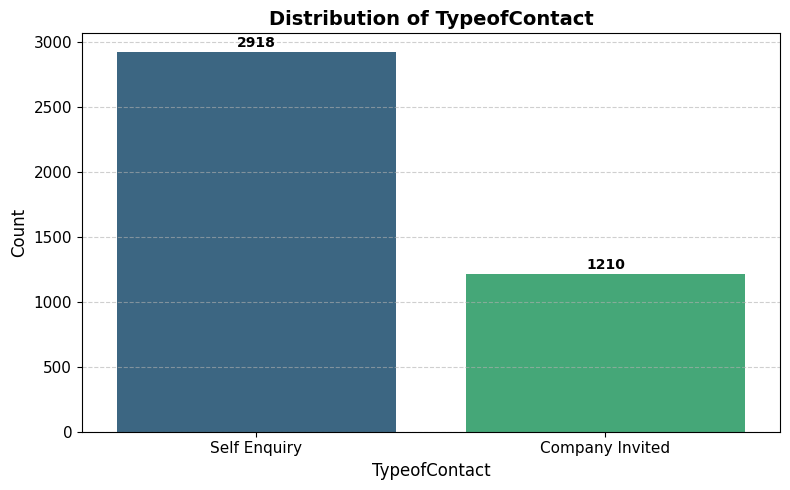

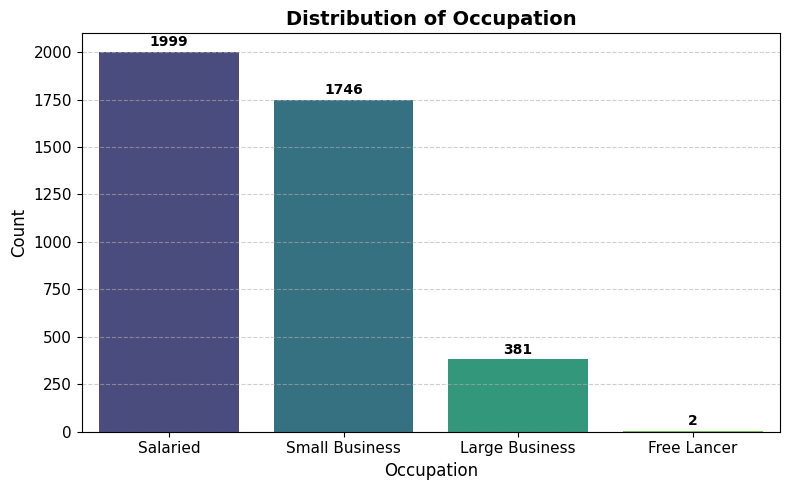

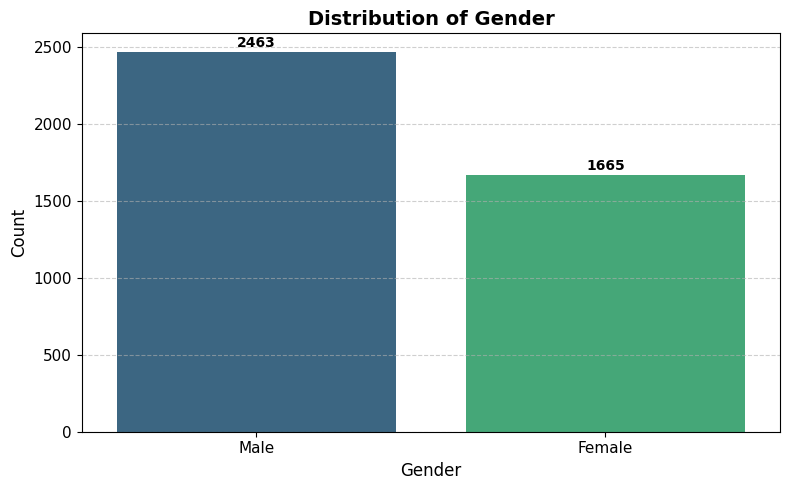

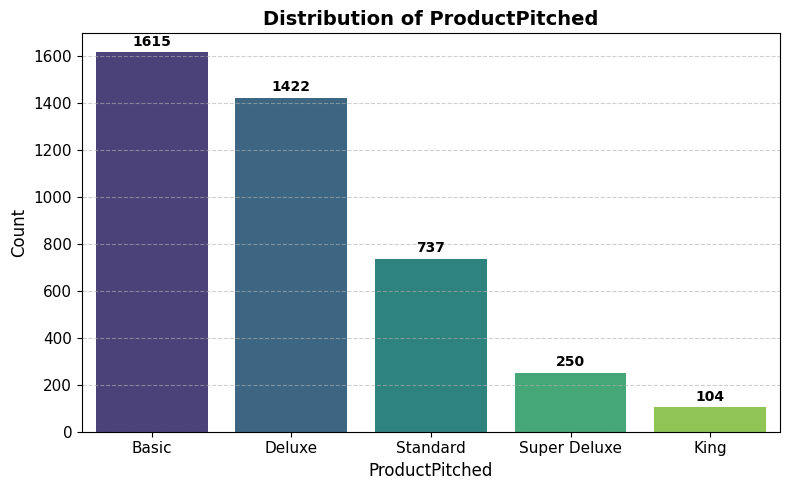

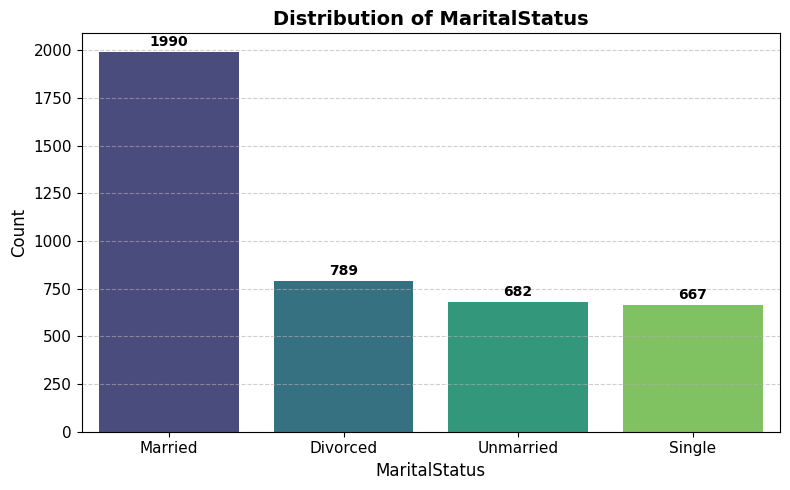

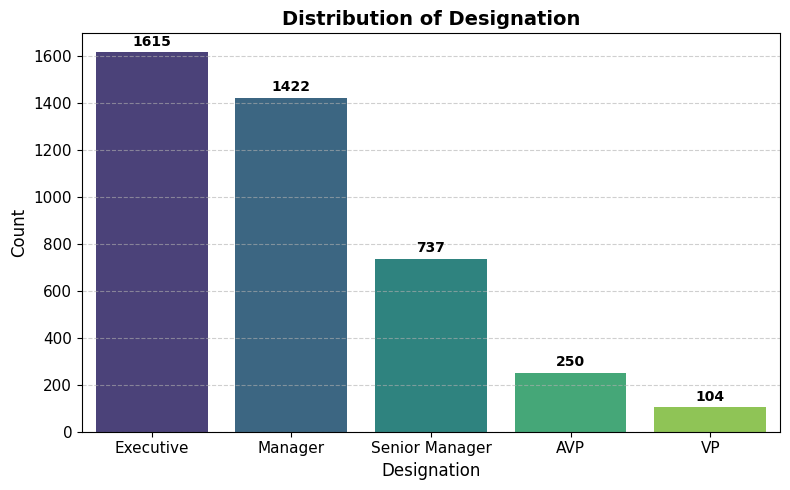

In [24]:
for col in catcols:
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(x=col, data=df, palette='viridis', order=df[col].value_counts().index)

    for p in ax.patches:
        height = p.get_height()
        ax.text(x = p.get_x() + p.get_width() / 2, y = height + 15, s = f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='semibold'
        )

    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    plt.tight_layout()
    plt.show()


<u>**Type Of Contact**</u>  
- Majority of the leads reached out through Self Enquiry (2918), while a smaller portion was **Company Invited (1210).  
- Indicates that customers are more proactive in seeking out the product.

---

<u>**Occupation**</u>  
- Most customers are Salaried (1999) or Small Business owners (1746).  
- Very few are from Large Business (381) or Free Lancer (2) category.  
- The customer base mainly consists of economically stable, working professionals consistent with earlier insights from descriptive stats.

---

<u>**Gender**</u>  
- More Male (2463) customers than Female (1665).  
- The gender imbalance might suggest targeted outreach or inherent interest differences.

---

<u>**Product Pitched**</u>  
- The Basic and Deluxe variants were pitched the most.  
- Very few received pitches for King and Super Deluxe.  
- Shows preference or strategic focus on mid-tier offerings.

---

<u>**Marital Status**</u>  
- Most customers are Married (1990).  
- Single, Unmarried, and Divorced customers form the minority.  
- This could indicate that family oriented individuals are more interested in the product.

---

<u>**Designation**</u>  
- Highest number of customers are at Executive (1615) and Manager (1422) levels.  
- Very few are VP (104) or AVP (250).  
- The product seems more popular or accessible among mid-level professionals.


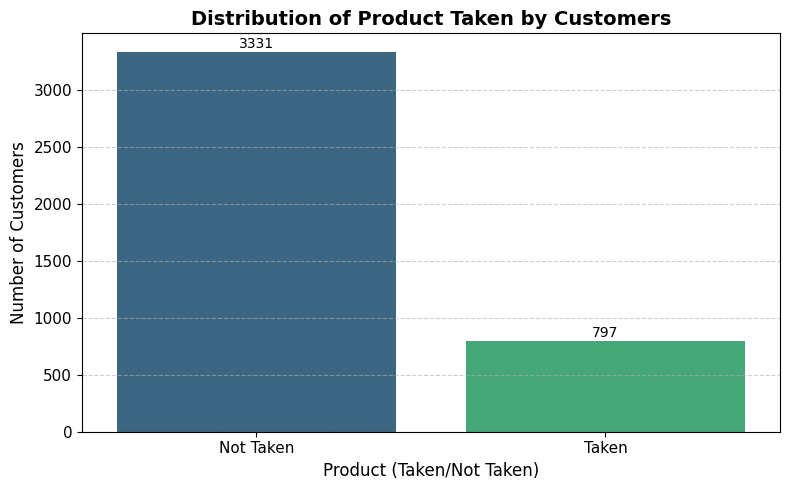

In [25]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='ProdTaken', data=df, palette='viridis')

for i in ax.patches:
    height = i.get_height()
    ax.text(x = i.get_x() + i.get_width()/2, y = i.get_y()+70 + height, s=f'{int(height)}', ha='center', va='center')


plt.title('Distribution of Product Taken by Customers', fontsize=14, fontweight='bold')
plt.xlabel('Product (Taken/Not Taken)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks([0, 1], ['Not Taken', 'Taken'], fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

- Only 19% of customers have taken the product, while 81% have not - indicating low conversion overall.

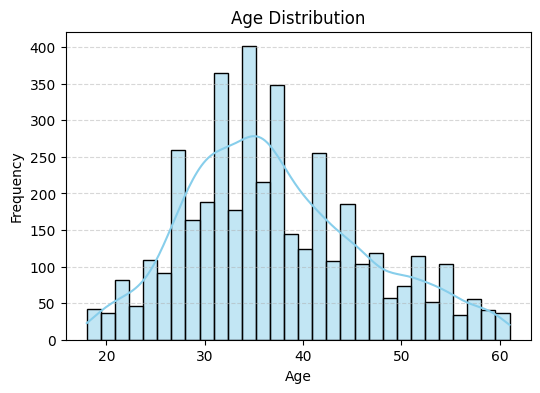

In [26]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=30, kde=True, color='skyblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


- The distribution is nearly normal with a slight right skew.
- The most frequent age group lies between 30 and 38 years.
- Majority of participants are aged between 25 and 45 years, showing concentration of middle-aged individuals.
- product likely targets working professionals or adults in early to mid-career stages.

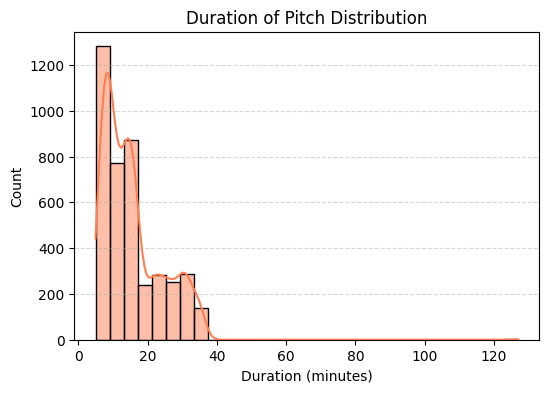

In [27]:
plt.figure(figsize=(6,4))
sns.histplot(df['DurationOfPitch'].dropna(), bins=30, kde=True, color='coral')
plt.title('Duration of Pitch Distribution')
plt.xlabel('Duration (minutes)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


- Right skewed distribution: most pitches are under 20 minutes.
- A large spike is seen between 5 and 15 minutes, with sharp drop-off afterward.
- Very few pitches exceed 40 minutes, with some outliers beyond 60 minutes.
- Most pitches are short and to the point, suggesting time efficiency or format constraints.
- Long pitches are rare and may represent in depth discussions.

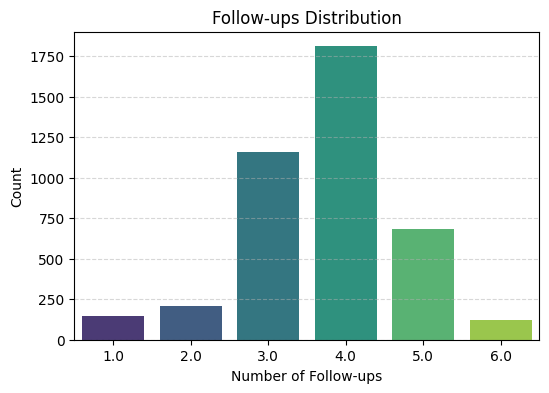

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(x='NumberOfFollowups', data=df, palette='viridis')
plt.title('Follow-ups Distribution')
plt.xlabel('Number of Follow-ups')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


- The highest number of followups is 4, followed by 3 and 5.
- Followup frequency is fairly structured , most people require multiple followups, possibly as part of a defined sales or feedback process.

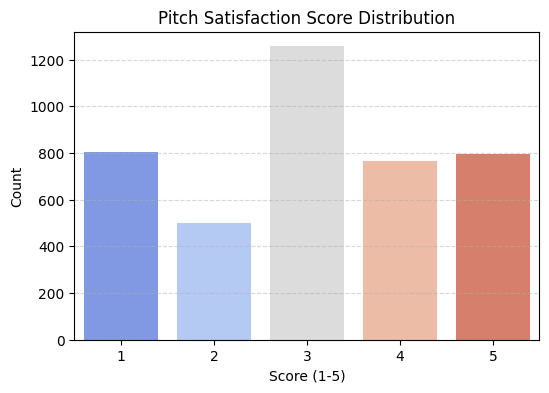

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(x='PitchSatisfactionScore', data=df, palette='coolwarm')
plt.title('Pitch Satisfaction Score Distribution')
plt.xlabel('Score (1-5)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


- Score 3 is the most common, followed by 1, 4, and 5, then 2.
- Satisfaction is mixed. Neutral feedback is common, but extremes (very satisfied/unsatisfied) are also prominent.

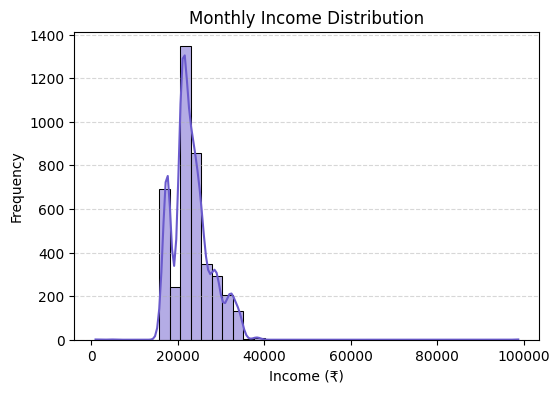

In [30]:
plt.figure(figsize=(6,4))
sns.histplot(df['MonthlyIncome'].dropna(), bins=40, kde=True, color='slateblue')
plt.title('Monthly Income Distribution')
plt.xlabel('Income (₹)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

- Right-skewed distribution: most individuals earn between ₹16,000 and ₹35,000
- There's a long tail stretching up to ₹1,00,000+, with very few high earners.
- Clear central peak around ₹20,000–₹25,000.
- Dataset includes mostly low to mid-income individuals.
---

**!**
some columns are stored as numerical types (int, float) but actually represent categorical information.

In [31]:
cat_convert_cols = [ 
    'CityTier', 
    'PreferredPropertyStar', 
    'Passport', 
    'OwnCar', 
    'PitchSatisfactionScore'
]

df[cat_convert_cols].dtypes

CityTier                    int64
PreferredPropertyStar     float64
Passport                    int64
OwnCar                      int64
PitchSatisfactionScore      int64
dtype: object

In [32]:
df[cat_convert_cols] = df[cat_convert_cols].astype('object')

In [33]:
catcols = df.columns[df.dtypes == 'object'].to_list() 
numcols = df.columns[df.dtypes != 'object'].to_list()

In [34]:
catcols

['TypeofContact',
 'CityTier',
 'Occupation',
 'Gender',
 'ProductPitched',
 'PreferredPropertyStar',
 'MaritalStatus',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'Designation']

In [35]:
numcols

['CustomerID',
 'ProdTaken',
 'Age',
 'DurationOfPitch',
 'NumberOfPersonVisiting',
 'NumberOfFollowups',
 'NumberOfTrips',
 'NumberOfChildrenVisiting',
 'MonthlyIncome',
 'GenderEncoded']

In [36]:
corr_matrix = df[numcols].corr(method='spearman')
corr_matrix

,CustomerID,ProdTaken,Age,DurationOfPitch,NumberOfPersonVisiting,NumberOfFollowups,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome,GenderEncoded
CustomerID,1.000000,0.057040,-0.010511,0.098315,0.601009,0.483612,0.268498,0.502891,0.289969,-0.006844
ProdTaken,0.057040,1.000000,-0.165235,0.087697,0.001127,0.106219,-0.008215,0.008280,-0.149565,0.028105
Age,-0.010511,-0.165235,1.000000,-0.027173,-0.016446,-0.033416,0.188997,-0.022239,0.415697,-0.026313
DurationOfPitch,0.098315,0.087697,-0.027173,1.000000,0.091573,0.020689,0.027881,0.053252,0.041316,0.017408
NumberOfPersonVisiting,0.601009,0.001127,-0.016446,0.091573,1.000000,0.366396,0.228328,0.582475,0.204390,-0.015943
NumberOfFollowups,0.483612,0.106219,-0.033416,0.020689,0.366396,1.000000,0.179854,0.320808,0.195444,-0.008333
NumberOfTrips,0.268498,-0.008215,0.188997,0.027881,0.228328,0.179854,1.000000,0.203401,0.172964,0.001497
NumberOfChildrenVisiting,0.502891,0.008280,-0.022239,0.053252,0.582475,0.320808,0.203401,1.000000,0.201147,0.018824
MonthlyIncome,0.289969,-0.149565,0.415697,0.041316,0.204390,0.195444,0.172964,0.201147,1.000000,-0.039993
GenderEncoded,-0.006844,0.028105,-0.026313,0.017408,-0.015943,-0.008333,0.001497,0.018824,-0.039993,1.000000


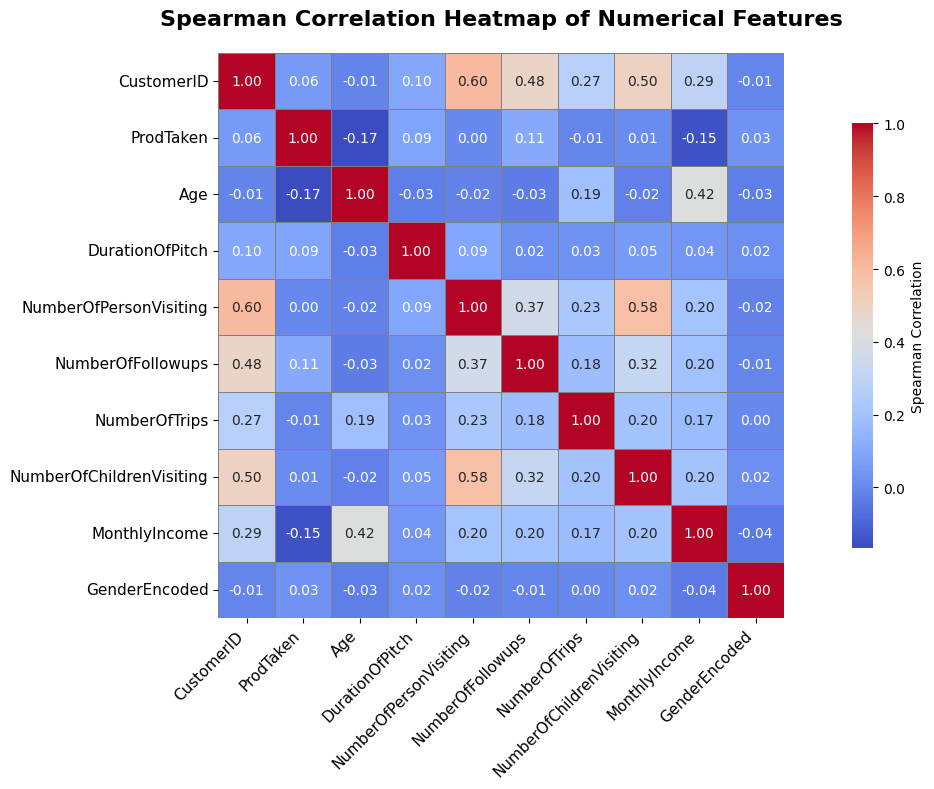

In [37]:
plt.figure(figsize=(14, 8))
ax = sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, linecolor='gray', square=True, cbar_kws={'shrink': 0.75, 'label': 'Spearman Correlation'})

plt.title('Spearman Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

##### **Key Insights**

**<u>NumberOfPersonVisiting</u>**  
- `c = 0.58` with `NumberOfChildrenVisiting` → More visitors usually include children – expected.  
- `c = 0.37` with `NumberOfFollowups` → More visitors may need more follow-ups.  
- `c = 0.20` with `MonthlyIncome` → Slight tendency: higher-income people bring more companions.

---

**<u>NumberOfChildrenVisiting</u>**
- `c = 0.58` with `NumberOfPersonVisiting` → Logical overlap.  
- `c = 0.32` with `NumberOfFollowups` → Families may require more follow-up efforts.  
- `c = 0.50` with `CustomerID` → Likely a position/index effect.

---

**<u>NumberOfFollowups</u>**
- `c = 0.37` with `NumberOfPersonVisiting` → Larger visiting groups trigger more follow-ups.  
- `c = 0.32` with `NumberOfChildrenVisiting` → Families likely need more follow-up attention.

---

**<u>MonthlyIncome</u>**
- `c = 0.41` with `Age` → Older individuals tend to earn more.  
- `c = -0.15` with `ProdTaken` → Higher income may reduce product uptake.

---

**<u>ProdTaken</u>**
- `c = -0.17` with `Age` → Younger individuals are more likely to purchase.  
- `c = -0.15` with `MonthlyIncome` → Slightly lower-income groups may show better conversion.  

---


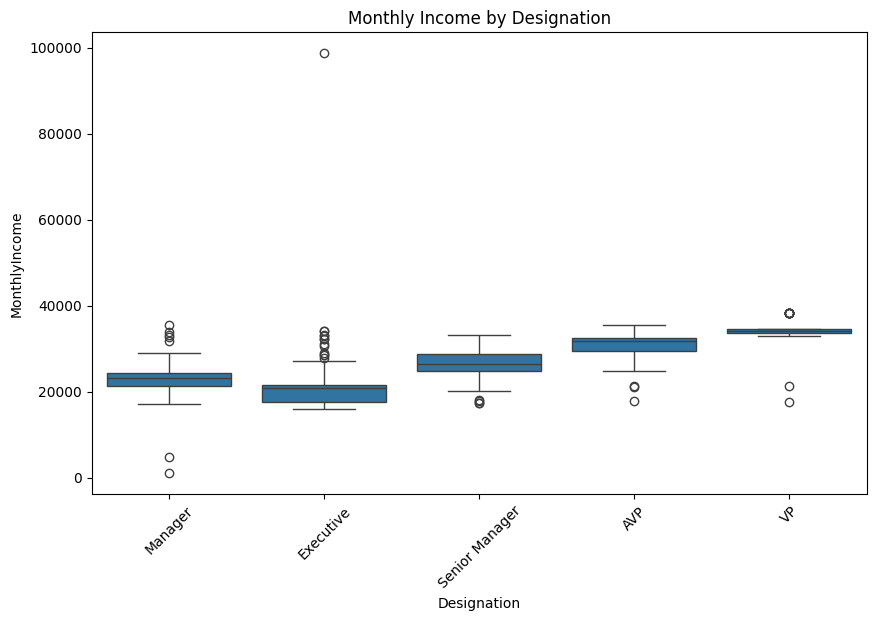

In [38]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Designation', y='MonthlyIncome', data=df)
plt.title('Monthly Income by Designation')
plt.xticks(rotation=45)
plt.show()

- The median monthly income generally increases with designation, from Manager to VP.
- There are several outliers with very high incomes, particularly in the Executive and Manager designations, as shown by the dots above the whiskers.

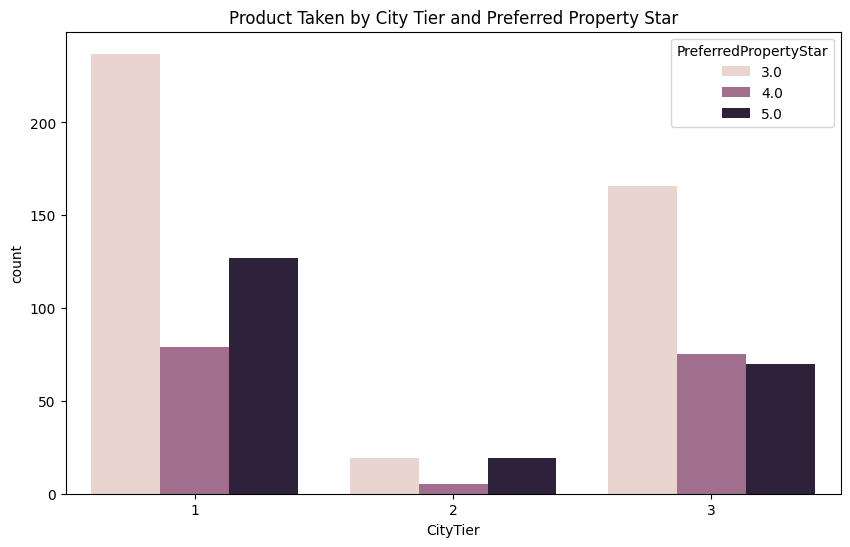

In [39]:
plt.figure(figsize=(10, 6))
sns.countplot(x='CityTier', hue='PreferredPropertyStar', data=df[df['ProdTaken'] == 1])
plt.title('Product Taken by City Tier and Preferred Property Star')
plt.show()


- City Tier 1 has the highest number of customers taking products, especially those who prefer 3.0-star properties.
- In City Tier 1 and 3, customers who prefer 3.0-star properties take the most products, while in City Tier 2, the total number of products taken is very low.
- Customers in City Tier 1 who prefer 5.0-star properties show a higher product uptake compared to their counterparts in other tiers.

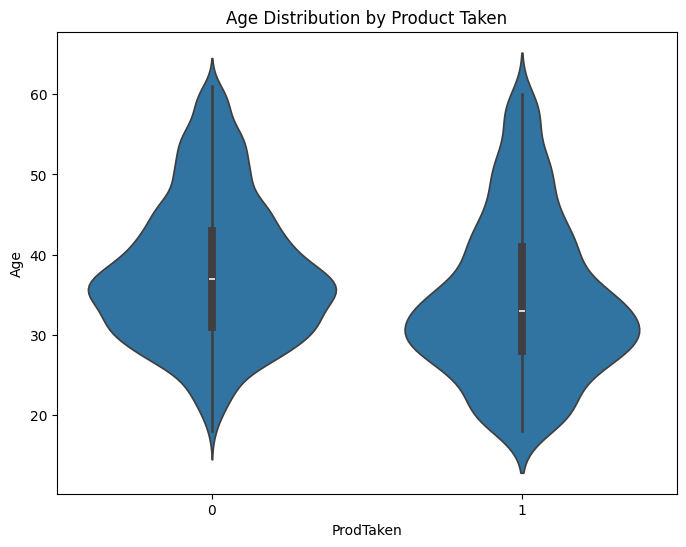

In [40]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='ProdTaken', y='Age', data=df, inner='box')
plt.title('Age Distribution by Product Taken')
plt.show()

- The age distributions for customers who took a product (1) and those who didn't (0) are very similar.
- The median age for both groups is around 35-37 years old.
- The violin plots show that the majority of customers are in their 20s, 30s, and 40s, with a few older customers in their 60s.

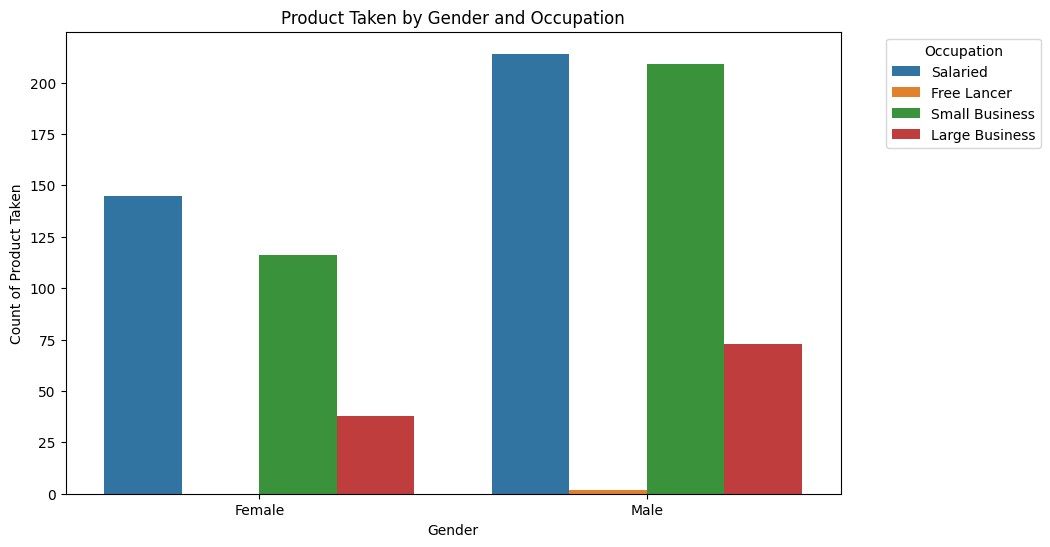

In [41]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Gender', hue='Occupation', data=df[df['ProdTaken'] == 1])
plt.title('Product Taken by Gender and Occupation')
plt.xlabel('Gender')
plt.ylabel('Count of Product Taken')
plt.legend(title='Occupation', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


- Salaried individuals take the most products across both genders, with males taking a significantly higher number than females.
- Small business owners also take a substantial number of products, especially males.

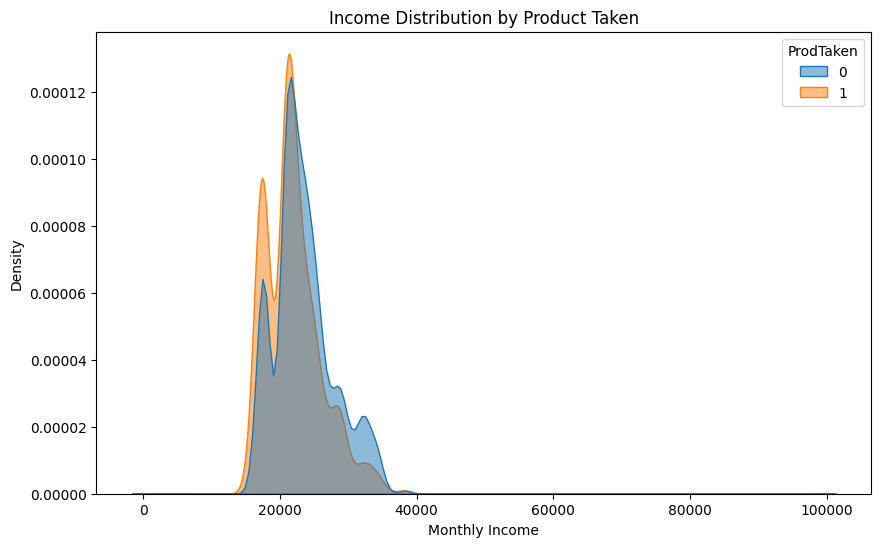

In [42]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='MonthlyIncome', hue='ProdTaken', fill=True, common_norm=False, alpha=0.5)
plt.title('Income Distribution by Product Taken')
plt.xlabel('Monthly Income')
plt.ylabel('Density')
plt.show()

- The monthly income distributions for both groups are heavily right-skewed, meaning most people have lower incomes.
- The distribution for those who took a product (1) is slightly shifted to the right, suggesting that customers with slightly higher incomes are more likely to take a product.

In [43]:
df.drop('CustomerID', axis=1, inplace=True)

In [44]:
df

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome,GenderEncoded
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0,0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0,1
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0,1
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0,0
5,0,32.0,Company Invited,1,8.0,Salaried,Male,3,3.0,Basic,3.0,Single,1.0,0,5,1,1.0,Executive,18068.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,1,49.0,Self Enquiry,3,9.0,Small Business,Male,3,5.0,Deluxe,4.0,Unmarried,2.0,1,1,1,1.0,Manager,26576.0,1
4884,1,28.0,Company Invited,1,31.0,Salaried,Male,4,5.0,Basic,3.0,Single,3.0,1,3,1,2.0,Executive,21212.0,1
4885,1,52.0,Self Enquiry,3,17.0,Salaried,Female,4,4.0,Standard,4.0,Married,7.0,0,1,1,3.0,Senior Manager,31820.0,0
4886,1,19.0,Self Enquiry,3,16.0,Small Business,Male,3,4.0,Basic,3.0,Single,3.0,0,5,0,2.0,Executive,20289.0,1


In [45]:
df['TotalVisiting'] = df['NumberOfPersonVisiting'] + df['NumberOfChildrenVisiting']
df

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,...,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome,GenderEncoded,TotalVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,...,Single,1.0,1,2,1,0.0,Manager,20993.0,0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,...,Divorced,2.0,0,3,1,2.0,Manager,20130.0,1,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,...,Single,7.0,1,3,0,0.0,Executive,17090.0,1,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,...,Divorced,2.0,1,5,1,1.0,Executive,17909.0,0,3.0
5,0,32.0,Company Invited,1,8.0,Salaried,Male,3,3.0,Basic,...,Single,1.0,0,5,1,1.0,Executive,18068.0,1,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,1,49.0,Self Enquiry,3,9.0,Small Business,Male,3,5.0,Deluxe,...,Unmarried,2.0,1,1,1,1.0,Manager,26576.0,1,4.0
4884,1,28.0,Company Invited,1,31.0,Salaried,Male,4,5.0,Basic,...,Single,3.0,1,3,1,2.0,Executive,21212.0,1,6.0
4885,1,52.0,Self Enquiry,3,17.0,Salaried,Female,4,4.0,Standard,...,Married,7.0,0,1,1,3.0,Senior Manager,31820.0,0,7.0
4886,1,19.0,Self Enquiry,3,16.0,Small Business,Male,3,4.0,Basic,...,Single,3.0,0,5,0,2.0,Executive,20289.0,1,5.0


In [46]:
df.drop(['NumberOfPersonVisiting','NumberOfChildrenVisiting'], axis=1, inplace=True)

In [56]:
catcols = df.select_dtypes(include = 'object').columns

In [55]:
numcols = df.select_dtypes(exclude = 'object').columns